In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [3]:
!pip install zarr gcsfs fsspec xarray --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 6.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 85.2 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.26.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
cudf-cu12 25.6.0 requires pyarrow<20.0.0a0,>=14.0.0; platform_machine == "x86_64", but you have pyarrow 22.0.0 which is incompatible.
gradio 5.49.1 requires pydantic<2.12,>=2.0, but you have pydantic 2.12.5 which is incompatible.
bigframes 2.26.0 requires rich<14,>=12.4.4, but you have rich 14.2.0 which is incompatible.


In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import numpy as np
import xarray as xr
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

In [5]:
class UpscaleDataset(Dataset):

    def __init__(
        self,
        zarr_path,
        *,                      # ⭐ force named args (prevents your old bug)
        in_scale=4,
        year_start,
        year_end,
        months=[6,7,8,9],
        constant_variables=["land_sea_mask","geopotential_at_surface"]
    ):

        print("\nOpening ERA5 Zarr...")
        print("in_scale =", in_scale)

        ds = xr.open_zarr(
            zarr_path,
            consolidated=True,
            storage_options={"token":"anon"}
        )

        # -------------------------
        # India region
        # -------------------------
        ds = ds.sel(latitude=slice(40,5),
                    longitude=slice(60,100))

        # -------------------------
        # DIVISIBLE BY 8 (3 pools)
        # -------------------------
        div = 8
        H = len(ds.latitude)
        W = len(ds.longitude)

        H = (H//div)*div
        W = (W//div)*div

        ds = ds.isel(latitude=slice(0,H),
                     longitude=slice(0,W))

        print("Grid:", H, "x", W)

        # -------------------------
        # Time filter
        # -------------------------
        ds = ds.sel(time=slice(f"{year_start}", f"{year_end}"))
        ds = ds.sel(time=ds.time.dt.month.isin(months))

        self.lon = ds.longitude
        self.lat = ds.latitude

        # -------------------------
        # Precipitation
        # -------------------------
        tp = ds["total_precipitation_12hr"].to_numpy().astype(np.float32)

        tp *= 1000
        tp = np.log1p(tp)

        fine = torch.from_numpy(tp).unsqueeze(1)

        # -------------------------
        # Coarsen
        # -------------------------
        H,W = fine.shape[-2:]

        assert H//in_scale > 0 and W//in_scale > 0, "Resize would become zero!"

        coarse = F.interpolate(fine, scale_factor=1/in_scale, mode="bilinear")
        coarse = F.interpolate(coarse, size=(H,W), mode="bilinear")

        residual = fine - coarse

        self.fine = fine
        self.coarse = coarse

        # normalize
        mean = coarse.mean()
        std  = coarse.std()

        self.inputs  = (coarse-mean)/std
        self.targets = (residual-residual.mean())/residual.std()

        self.inverse = lambda r: r*residual.std() + residual.mean()

        # -------------------------
        # constants
        # -------------------------
        if constant_variables:
            consts=[]
            for var in constant_variables:
                arr = ds[var].to_numpy().astype(np.float32)
                arr = (arr-arr.mean())/arr.std()
                consts.append(torch.from_numpy(arr))

            const = torch.stack(consts,0)
            const = const.unsqueeze(0).repeat(self.inputs.shape[0],1,1,1)

            self.inputs = torch.cat((self.inputs,const),1)

        # -------------------------
        # time embeddings
        # -------------------------
        t = ds.time.dt

        self.day_of_year = torch.from_numpy(
            ((t.month.values-1)*30)/360
        ).float()

        self.hour = torch.from_numpy(
            t.hour.values/24
        ).float()

        print("Inputs :", self.inputs.shape)
        print("Targets:", self.targets.shape)


    def __len__(self):
        return len(self.inputs)


    def __getitem__(self, idx):
        return {
            "inputs":self.inputs[idx],
            "targets":self.targets[idx],
            "fine":self.fine[idx],
            "coarse":self.coarse[idx],
            "day_of_year":self.day_of_year[idx],
            "hour":self.hour[idx]
            # "mslp":self.,
            # "10m_component_wind":
        }


    def residual_to_fine(self, r, coarse):
        return coarse + self.inverse(r)

In [6]:
class Block(nn.Module):
    def __init__(self,in_c,out_c,emb_dim):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(in_c,out_c,3,padding=1),
            nn.GroupNorm(8,out_c),
            nn.SiLU(),
            nn.Conv2d(out_c,out_c,3,padding=1),
            nn.GroupNorm(8,out_c),
            nn.SiLU()
        )

        self.emb = nn.Linear(emb_dim,out_c)

    def forward(self,x,e):
        h = self.net(x)
        return h + self.emb(e).unsqueeze(-1).unsqueeze(-1)


class UNet(nn.Module):

    def __init__(self,in_c,out_c):
        super().__init__()

        base=32
        emb_dim=128

        self.embed = nn.Sequential(
            nn.Linear(2,emb_dim),
            nn.SiLU(),
            nn.Linear(emb_dim,emb_dim)
        )

        self.pool=nn.MaxPool2d(2)
        self.up  =nn.Upsample(scale_factor=2,mode="bilinear")

        self.d1=Block(in_c,base,emb_dim)
        self.d2=Block(base,base*2,emb_dim)
        self.d3=Block(base*2,base*4,emb_dim)

        self.mid=Block(base*4,base*8,emb_dim)

        self.u3=Block(base*8+base*4,base*4,emb_dim)
        self.u2=Block(base*4+base*2,base*2,emb_dim)
        self.u1=Block(base*2+base,base,emb_dim)

        self.out=nn.Conv2d(base,out_c,1)


    def forward(self,x,cond):

        e=self.embed(cond)

        d1=self.d1(x,e)
        d2=self.d2(self.pool(d1),e)
        d3=self.d3(self.pool(d2),e)

        m=self.mid(self.pool(d3),e)

        u3=self.u3(torch.cat([self.up(m),d3],1),e)
        u2=self.u2(torch.cat([self.up(u3),d2],1),e)
        u1=self.u1(torch.cat([self.up(u2),d1],1),e)

        return self.out(u1)

In [7]:
# ── Weighted MSE loss ─────────────────────────────────────────
class WeightedMSELoss(nn.Module):
    """
    w(y_true) = 1 + alpha * sigmoid((y_true - 20) / tau)
    Upweights high-value targets (y >> 20) during training.
    """
    def __init__(self, alpha: float = 2.0, tau: float = 5.0):
        super().__init__()
        self.alpha = alpha
        self.tau   = tau
 
    def forward(self, pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        weights = 1.0 + self.alpha * torch.sigmoid((target - 10.0) / self.tau)
        return (weights * (pred - target) ** 2).mean()

In [8]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 1 — Metrics · train_epoch                             ║
# ╚══════════════════════════════════════════════════════════════╝

import torch
import torch.nn as nn
import numpy as np
import xarray as xr


# ── Metrics ───────────────────────────────────────────────────
def compute_metrics(pred: torch.Tensor, gt: torch.Tensor):
    """Returns mse, mae, r2 as Python floats."""
    mse    = ((pred - gt) ** 2).mean().item()
    mae    = (pred - gt).abs().mean().item()
    ss_res = ((pred - gt) ** 2).sum()
    ss_tot = ((gt - gt.mean()) ** 2).sum()
    r2     = (1 - ss_res / ss_tot).item()
    return mse, mae, r2


def compute_percentile_errors(pred_np: np.ndarray, gt_np: np.ndarray):
    """
    Splits samples into three bands by |gt| magnitude and returns
    mean absolute error inside each band.
      p50  → bottom 50 % of |gt|  (low-value region)
      p95  → 50th–95th %ile       (moderate-value region)
      p99  → top 1 %              (extreme-value region, most weighted by loss)
    """
    err    = np.abs(pred_np - gt_np)
    gt_mag = np.abs(gt_np)
    t50, t95, t99 = np.percentile(gt_mag, [50, 95, 99])

    mask50 = gt_mag <= t50
    mask95 = (gt_mag > t50) & (gt_mag <= t95)
    mask99 = gt_mag > t99          # strict >99th, not the 95-99 band

    e50 = float(err[mask50].mean()) if mask50.any() else float("nan")
    e95 = float(err[mask95].mean()) if mask95.any() else float("nan")
    e99 = float(err[mask99].mean()) if mask99.any() else float("nan")
    return e50, e95, e99


def compute_crps(ens: xr.Dataset, truth: xr.Dataset, sample_dim: str = "sample") -> xr.Dataset:
    """
    Compute CRPS for each variable in `ens` vs `truth` along `sample_dim`.
    Returns a Dataset with same non-sample dims/coords (no sample dim).
    Uses properscoring if available; otherwise uses the exact identity:
      CRPS = mean_i |X_i - y|  -  0.5 * mean_{i,j} |X_i - X_j|
    """
    try:
        from properscoring import crps_ensemble as _crps_ens
        use_ps = True
    except Exception:
        use_ps = False

    out = {}
    common = [v for v in ens.data_vars if v in truth.data_vars and sample_dim in ens[v].dims]
    if not common:
        raise ValueError(f"No common variables with dim '{sample_dim}' to compute CRPS.")

    for v in common:
        y = truth[v]
        X = ens[v]
        y_al, X_al = xr.align(y, X, join="inner")

        if use_ps:
            crps = xr.apply_ufunc(
                _crps_ens,
                y_al, X_al,
                input_core_dims=[[], [sample_dim]],
                output_core_dims=[[]],
                vectorize=True,
                dask="parallelized",
                output_dtypes=[np.float32],
            )
        else:
            # Exact identity (no approximation), vectorized over remaining dims
            # X: (..., S), y: (...)
            Xv = X_al.transpose(..., sample_dim).values   # (..., S)
            yv = y_al.values                               # (...)
            # term1 = mean_i |X_i - y|
            term1 = np.mean(np.abs(Xv - np.expand_dims(yv, axis=-1)), axis=-1)
            # term2 = 0.5 * mean_{i,j} |X_i - X_j|
            Xi  = np.expand_dims(Xv, axis=-2)             # (..., 1, S)
            Xj  = np.expand_dims(Xv, axis=-1)             # (..., S, 1)
            mad = np.mean(np.abs(Xi - Xj), axis=(-2, -1)) # (...)
            crps = xr.DataArray(
                (term1 - 0.5 * mad).astype(np.float32),
                coords=y_al.coords,
                dims=y_al.dims,
            )

        crps.name = f"{v}_crps"
        out[v] = crps

    return xr.Dataset(out)


# ── Single training epoch ─────────────────────────────────────
def train_epoch(model, loader, optimizer, loss_fn, device):
    model.train()
    total = 0.0
    for b in loader:
        x    = b["inputs"].to(device)
        cond = torch.stack((b["day_of_year"], b["hour"]), 1).to(device)
        y    = b["fine"].to(device)
        optimizer.zero_grad()
        loss = loss_fn(model(x, cond), y)
        loss.backward()
        optimizer.step()
        total += loss.item()
    return total / len(loader)


print("✓ Cell 1 loaded — helpers ready")

✓ Cell 1 loaded — helpers ready



Opening ERA5 Zarr...
in_scale = 4
Grid: 136 x 160
Inputs : torch.Size([976, 3, 136, 160])
Targets: torch.Size([976, 1, 136, 160])

Opening ERA5 Zarr...
in_scale = 4
Grid: 136 x 160
Inputs : torch.Size([488, 3, 136, 160])
Targets: torch.Size([488, 1, 136, 160])

Epoch 01/1  ★ best saved
  Train  │ loss: 0.0930  MAE: 0.2524  R²: 0.8230
  Val    │ MSE:  0.1409  MAE: 0.2463  R²: 0.8251  CRPS: 0.2463
  Pct err│ 50th: 0.0973  95th: 0.3779  99th: 0.5898

Done. Best val MSE: 0.1409  →  /kaggle/working/best_model.pt


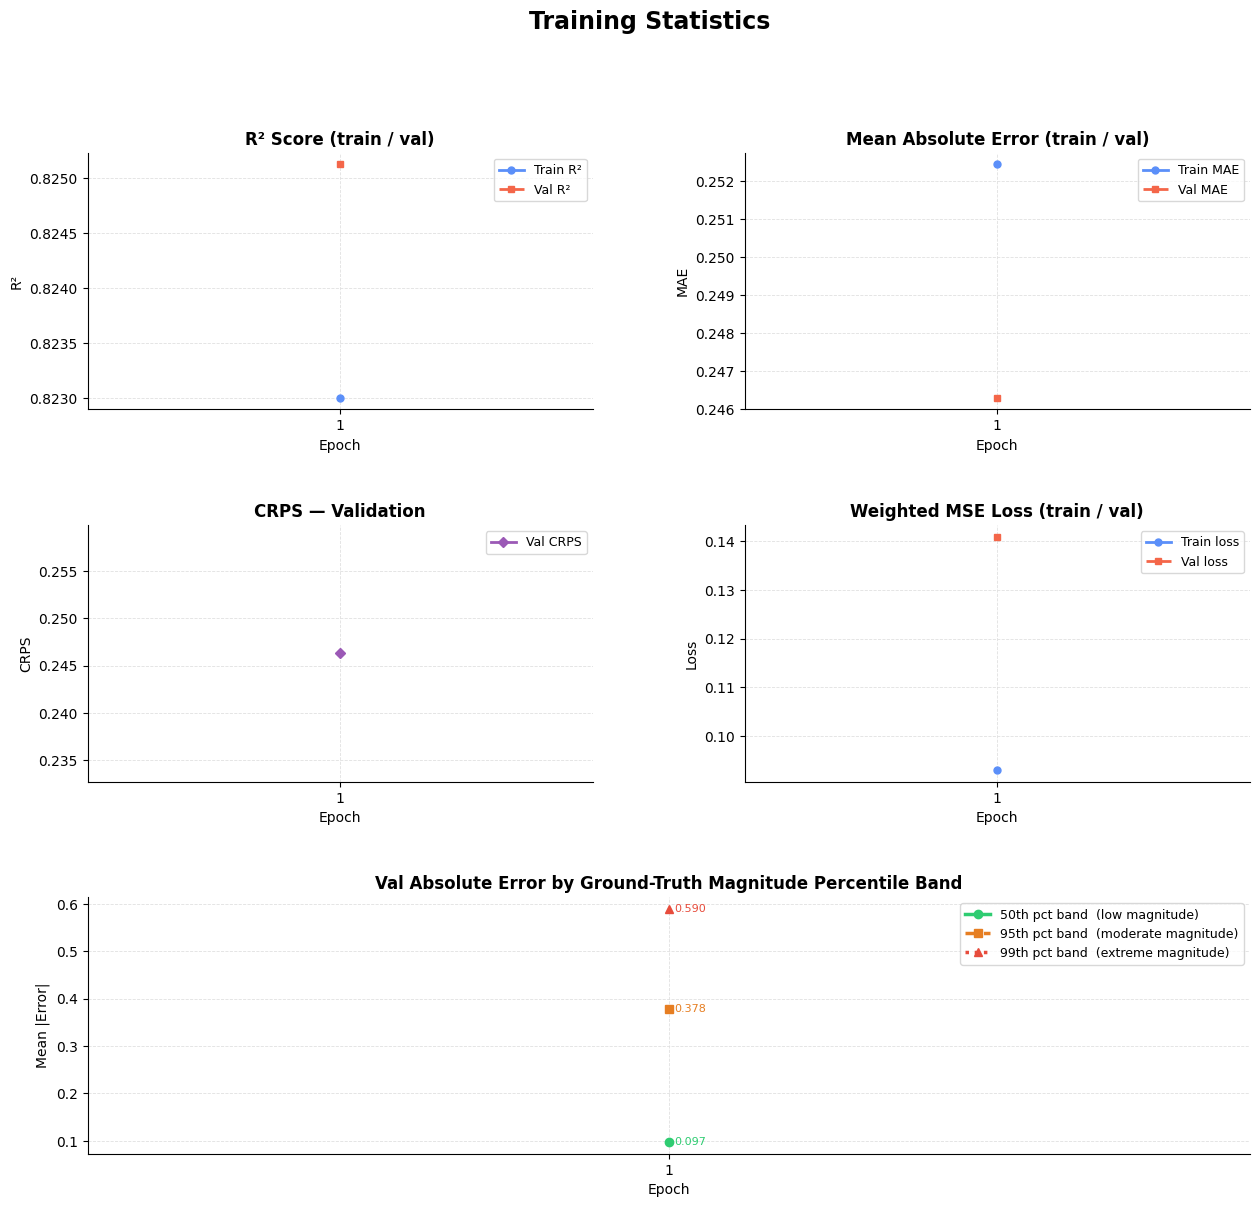

[plot] Saved → /kaggle/working/training_stats.png


In [9]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 2 — Training loop (run this to train)                 ║
# ╚══════════════════════════════════════════════════════════════╝

import torch
import torch.nn as nn
import numpy as np
import xarray as xr
from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"

zarr_path = (
    "gs://weatherbench2/datasets/era5/"
    "1959-2023_01_10-wb13-6h-1440x721_with_derived_variables.zarr"
)

train_ds     = UpscaleDataset(zarr_path=zarr_path, year_start=2016, year_end=2017)
valid_ds     = UpscaleDataset(zarr_path=zarr_path, year_start=2018, year_end=2018)
train_loader = DataLoader(train_ds, batch_size=8, shuffle=True,  num_workers=2)
valid_loader = DataLoader(valid_ds, batch_size=8, shuffle=False, num_workers=2)

model     = UNet(train_ds.inputs.shape[1], train_ds.targets.shape[1]).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)
loss_fn   = nn.MSELoss()
# loss_fn   = WeightedMSELoss(alpha=2.0, tau=5.0)

# ── history dict (consumed by Cell 3 for plotting) ────────────
history = dict(
    train_loss=[], val_loss=[],
    train_r2=[], val_r2=[],
    train_mae=[], val_mae=[],
    val_crps=[],
    val_p50=[], val_p95=[], val_p99=[],   # ← percentile error bands
    val_preds=[],                          # kept for percentile plot
    val_gts=[],
)

best_val_mse    = float("inf")
CHECKPOINT_PATH = "/kaggle/working/best_model.pt"
NUM_EPOCHS      = 1

# ─────────────────────────────────────────────────────────────
for epoch in range(NUM_EPOCHS):

    # ── train ────────────────────────────────────────────────
    train_loss = train_epoch(model, train_loader, optimizer, loss_fn, device)

    # ── train-set inference (for R² / MAE curves) ────────────
    model.eval()
    tr_preds, tr_gts = [], []
    with torch.no_grad():
        for b in train_loader:
            x    = b["inputs"].to(device)
            cond = torch.stack((b["day_of_year"], b["hour"]), 1).to(device)
            p    = valid_ds.residual_to_fine(model(x, cond).cpu(), b["coarse"])
            tr_preds.append(p);  tr_gts.append(b["fine"])
    tr_preds = torch.cat(tr_preds);  tr_gts = torch.cat(tr_gts)
    _,  tr_mae, tr_r2 = compute_metrics(tr_preds, tr_gts)

    # ── validation inference ──────────────────────────────────
    vp, vg = [], []
    with torch.no_grad():
        for b in valid_loader:
            x    = b["inputs"].to(device)
            cond = torch.stack((b["day_of_year"], b["hour"]), 1).to(device)
            p    = valid_ds.residual_to_fine(model(x, cond).cpu(), b["coarse"])
            vp.append(p);  vg.append(b["fine"])
    val_preds = torch.cat(vp);  val_gts = torch.cat(vg)

    val_mse, val_mae, val_r2 = compute_metrics(val_preds, val_gts)
    val_loss                 = loss_fn(val_preds, val_gts).item()

    # ── CRPS via exact ensemble identity ─────────────────────
    vp_np = val_preds.numpy().reshape(-1).astype(np.float32)
    vg_np = val_gts.numpy().reshape(-1).astype(np.float32)
    ens_ds   = xr.Dataset({"value": xr.DataArray(
                   vp_np[np.newaxis, :], dims=["sample", "pixel"])})
    truth_ds = xr.Dataset({"value": xr.DataArray(vg_np, dims=["pixel"])})
    val_crps = float(compute_crps(ens_ds, truth_ds, sample_dim="sample")["value"].values.mean())

    # ── percentile error bands ────────────────────────────────
    vp_np = val_preds.numpy();  vg_np = val_gts.numpy()
    e50, e95, e99 = compute_percentile_errors(vp_np, vg_np)

    # ── best-model checkpoint ─────────────────────────────────
    if val_mse < best_val_mse:
        best_val_mse = val_mse
        torch.save(
            dict(
                epoch            = epoch,
                model_state      = model.state_dict(),
                optimizer_state  = optimizer.state_dict(),
                val_mse=val_mse, val_mae=val_mae,
                val_r2=val_r2,   val_crps=val_crps,
            ),
            CHECKPOINT_PATH,
        )
        ckpt_tag = "  ★ best saved"
    else:
        ckpt_tag = ""

    # ── append to history ─────────────────────────────────────
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_r2"].append(tr_r2);    history["val_r2"].append(val_r2)
    history["train_mae"].append(tr_mae);  history["val_mae"].append(val_mae)
    history["val_crps"].append(val_crps)
    history["val_p50"].append(e50)
    history["val_p95"].append(e95)
    history["val_p99"].append(e99)
    history["val_preds"].append(vp_np)
    history["val_gts"].append(vg_np)

    # ── per-epoch print ───────────────────────────────────────
    print(
        f"\nEpoch {epoch+1:02d}/{NUM_EPOCHS}{ckpt_tag}\n"
        f"  Train  │ loss: {train_loss:.4f}  MAE: {tr_mae:.4f}  R²: {tr_r2:.4f}\n"
        f"  Val    │ MSE:  {val_mse:.4f}  MAE: {val_mae:.4f}  "
        f"R²: {val_r2:.4f}  CRPS: {val_crps:.4f}\n"
        f"  Pct err│ 50th: {e50:.4f}  95th: {e95:.4f}  99th: {e99:.4f}"
    )

print(f"\nDone. Best val MSE: {best_val_mse:.4f}  →  {CHECKPOINT_PATH}")


# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 3 — Plotting  (run after Cell 2)                      ║
# ╚══════════════════════════════════════════════════════════════╝

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

PLOT_PATH = "/kaggle/working/training_stats.png"
epochs    = list(range(1, len(history["train_loss"]) + 1))

C = dict(
    blue="#5B8FF9", orange="#F46649", purple="#9B59B6",
    p50="#2ECC71",  p95="#E67E22",   p99="#E74C3C",
    grid="#E0E0E0",
)

fig = plt.figure(figsize=(15, 13), facecolor="white")
fig.suptitle("Training Statistics", fontsize=17, fontweight="bold", y=0.99)
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.30)

ax_r2   = fig.add_subplot(gs[0, 0])
ax_mae  = fig.add_subplot(gs[0, 1])
ax_crps = fig.add_subplot(gs[1, 0])
ax_loss = fig.add_subplot(gs[1, 1])
ax_pct  = fig.add_subplot(gs[2, :])


def _style(ax, title, ylabel):
    ax.set_title(title, fontsize=12, fontweight="bold", pad=6)
    ax.set_xlabel("Epoch", fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.grid(True, color=C["grid"], linewidth=0.6, linestyle="--")
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(fontsize=9, framealpha=0.75)
    ax.set_xticks(epochs)


# ── R² ──────────────────────────────────────────────────────
ax_r2.plot(epochs, history["train_r2"], color=C["blue"],   lw=2,
           marker="o", ms=5, label="Train R²")
ax_r2.plot(epochs, history["val_r2"],   color=C["orange"], lw=2,
           marker="s", ms=5, label="Val R²", linestyle="--")
_style(ax_r2, "R² Score (train / val)", "R²")

# ── MAE ─────────────────────────────────────────────────────
ax_mae.plot(epochs, history["train_mae"], color=C["blue"],   lw=2,
            marker="o", ms=5, label="Train MAE")
ax_mae.plot(epochs, history["val_mae"],   color=C["orange"], lw=2,
            marker="s", ms=5, label="Val MAE", linestyle="--")
_style(ax_mae, "Mean Absolute Error (train / val)", "MAE")

# ── CRPS ────────────────────────────────────────────────────
ax_crps.plot(epochs, history["val_crps"], color=C["purple"], lw=2,
             marker="D", ms=5, label="Val CRPS")
_style(ax_crps, "CRPS — Validation", "CRPS")

# ── Weighted loss ────────────────────────────────────────────
ax_loss.plot(epochs, history["train_loss"], color=C["blue"],   lw=2,
             marker="o", ms=5, label="Train loss")
ax_loss.plot(epochs, history["val_loss"],   color=C["orange"], lw=2,
             marker="s", ms=5, label="Val loss", linestyle="--")
_style(ax_loss, "Weighted MSE Loss (train / val)", "Loss")

# ── Percentile error bands ────────────────────────────────────
ax_pct.plot(epochs, history["val_p50"], color=C["p50"], lw=2.5,
            marker="o", ms=6, label="50th pct band  (low magnitude)")
ax_pct.plot(epochs, history["val_p95"], color=C["p95"], lw=2.5,
            marker="s", ms=6, label="95th pct band  (moderate magnitude)", linestyle="--")
ax_pct.plot(epochs, history["val_p99"], color=C["p99"], lw=2.5,
            marker="^", ms=6, label="99th pct band  (extreme magnitude)", linestyle=":")

# annotate final-epoch values
for key, col, vals in [
    ("p50", C["p50"], history["val_p50"]),
    ("p95", C["p95"], history["val_p95"]),
    ("p99", C["p99"], history["val_p99"]),
]:
    ax_pct.annotate(
        f"{vals[-1]:.3f}",
        xy=(epochs[-1], vals[-1]),
        xytext=(4, 0), textcoords="offset points",
        fontsize=8, color=col, va="center",
    )

_style(ax_pct, "Val Absolute Error by Ground-Truth Magnitude Percentile Band",
       "Mean |Error|")

plt.savefig(PLOT_PATH, dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print(f"[plot] Saved → {PLOT_PATH}")

  Running inference for 2019 … 
Opening ERA5 Zarr...
in_scale = 4
Grid: 136 x 160
Inputs : torch.Size([488, 3, 136, 160])
Targets: torch.Size([488, 1, 136, 160])
done
  Running inference for 2020 … 
Opening ERA5 Zarr...
in_scale = 4
Grid: 136 x 160
Inputs : torch.Size([488, 3, 136, 160])
Targets: torch.Size([488, 1, 136, 160])
done
  Running inference for 2021 … 
Opening ERA5 Zarr...
in_scale = 4
Grid: 136 x 160
Inputs : torch.Size([488, 3, 136, 160])
Targets: torch.Size([488, 1, 136, 160])
done
  Running inference for 2022 … 
Opening ERA5 Zarr...
in_scale = 4
Grid: 136 x 160
Inputs : torch.Size([488, 3, 136, 160])
Targets: torch.Size([488, 1, 136, 160])
done


/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_1_states_provinces_lakes.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_rivers_lake_centerlines.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:24

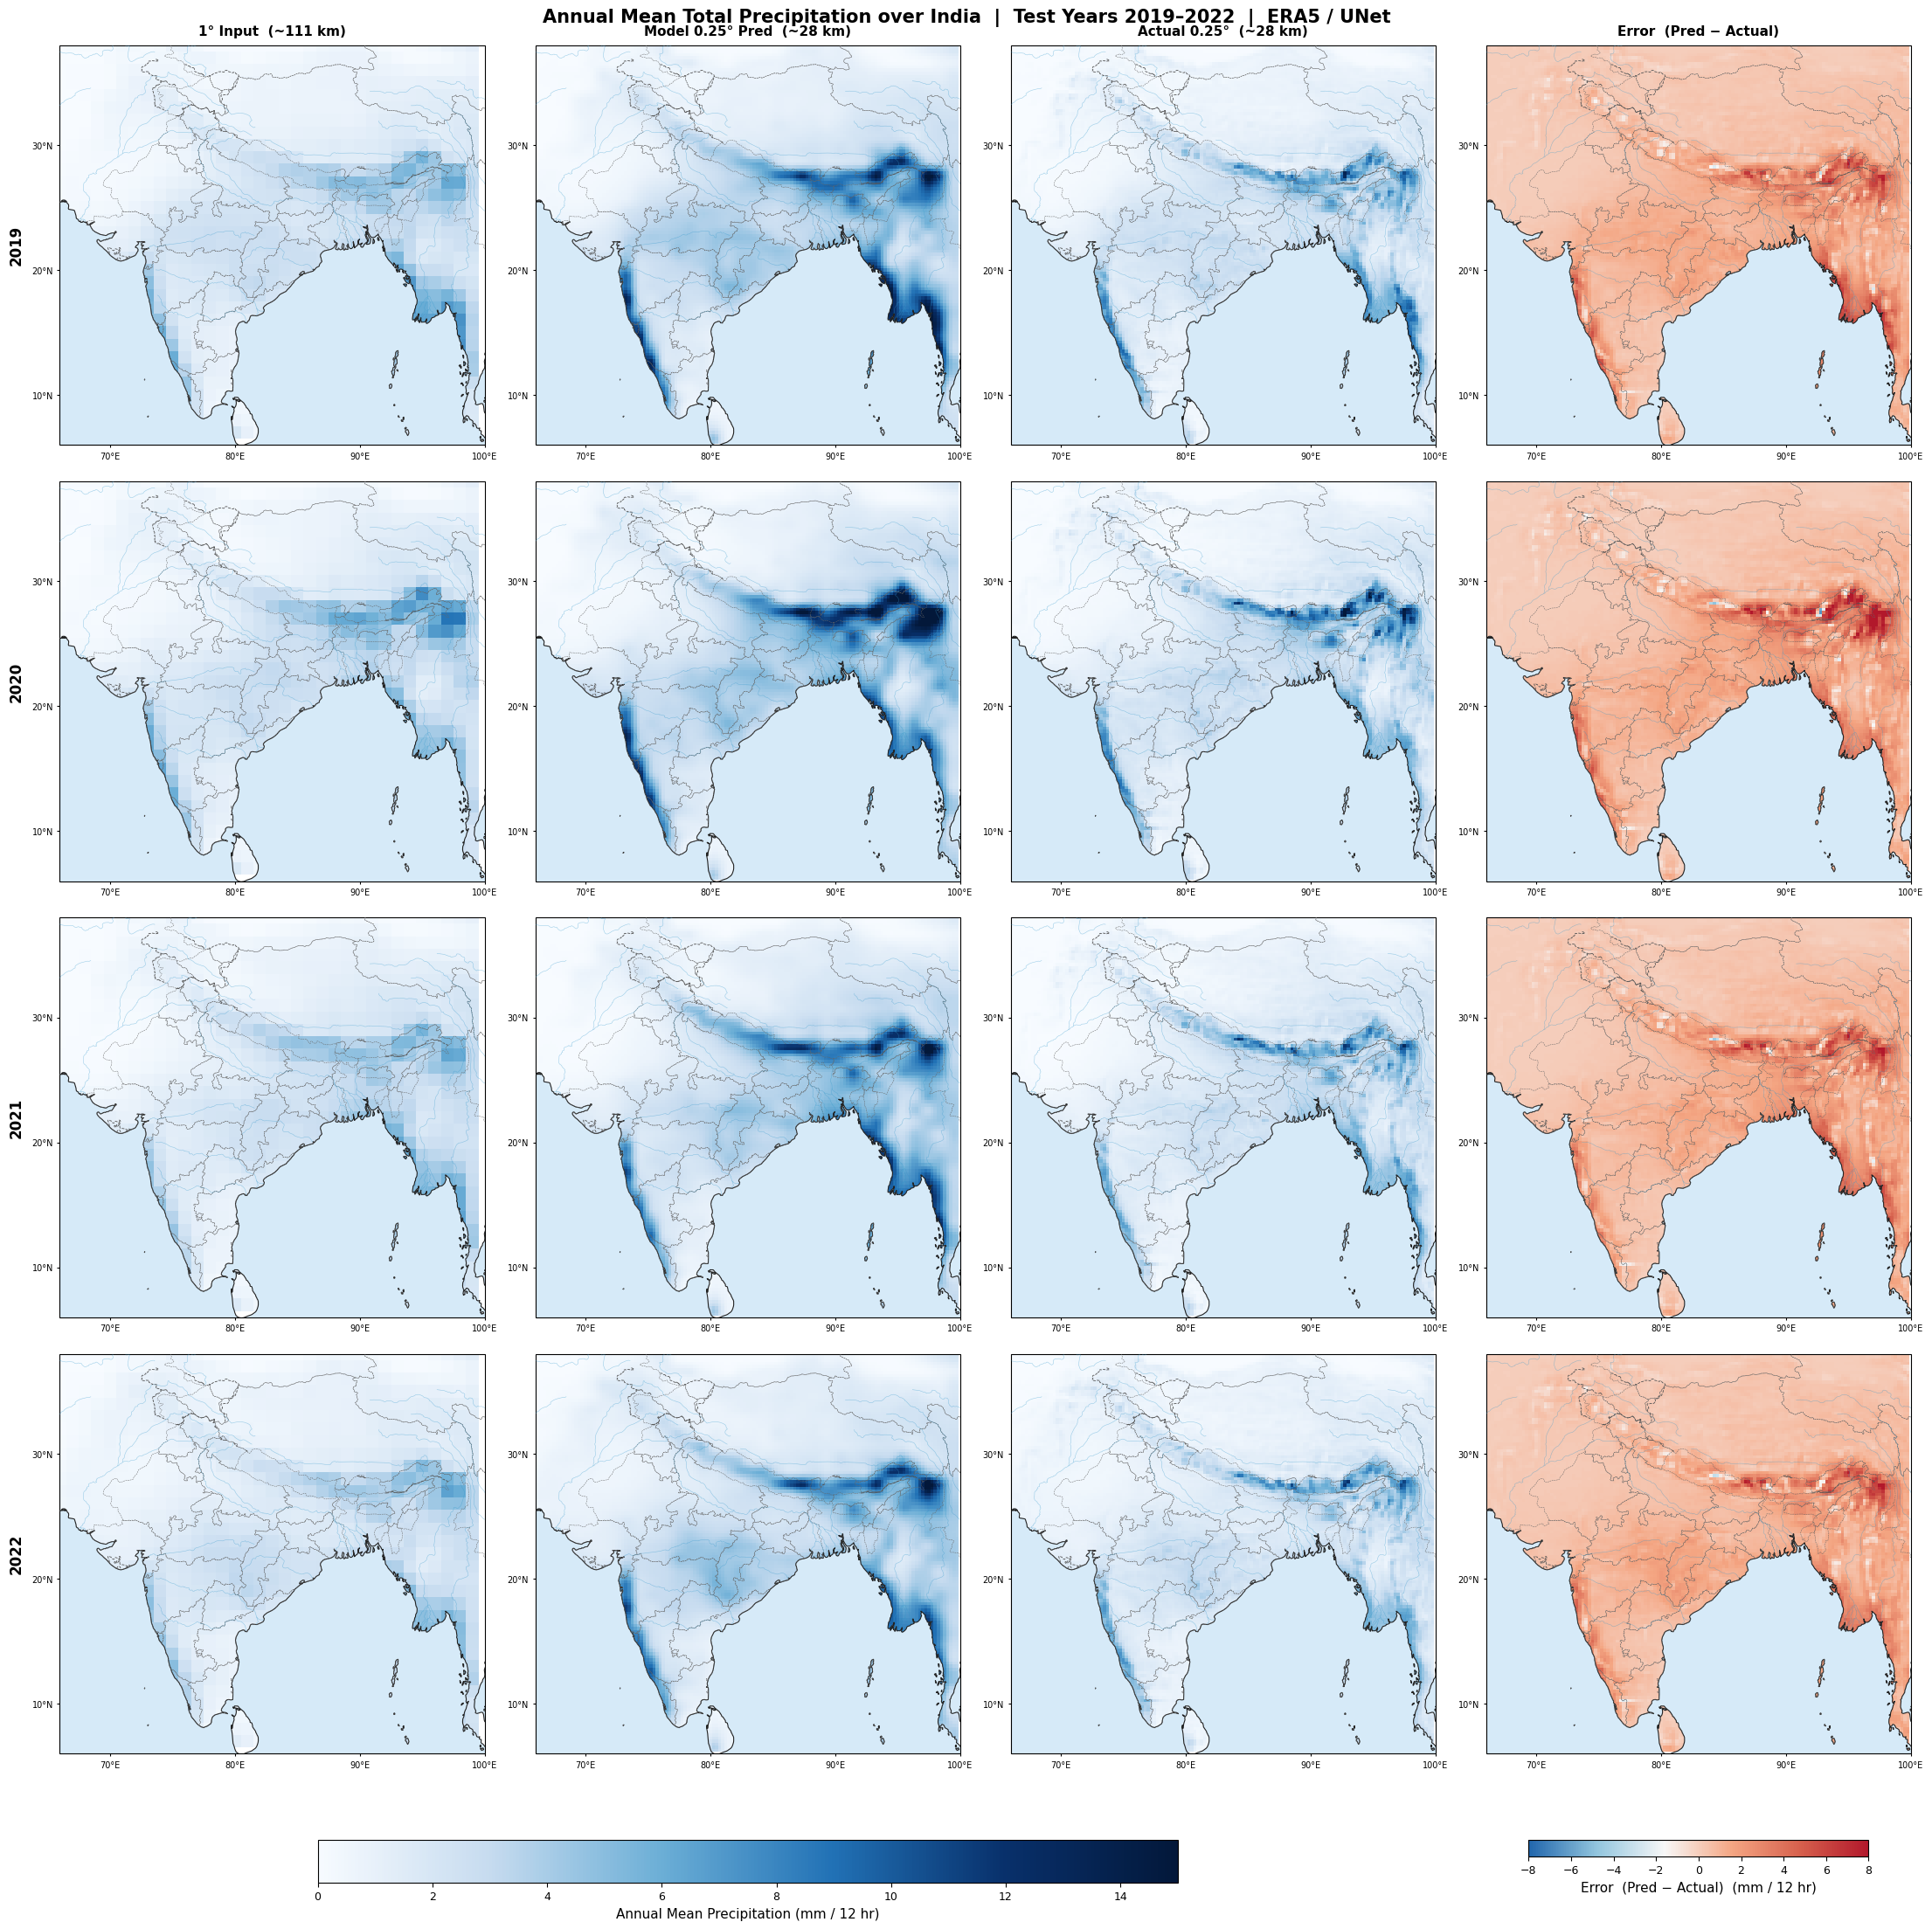

Done → /kaggle/working/india_test_yearwise.png


In [13]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 4 — Year-wise India test plots  (2019 – 2022)                        ║
# ║  Rows : one per year  (mean over that year's test predictions)              ║
# ║  Cols : 1° Input  |  Model 0.25° pred  |  Actual 0.25°  |  Error           ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import torch
import xarray as xr
from torch.utils.data import DataLoader

# ── Region ────────────────────────────────────────────────────────────────────
LAT_MIN, LAT_MAX =  6.0, 38.0
LON_MIN, LON_MAX = 66.0, 100.0

# ── Resolution grids (same convention as reference code) ─────────────────────
lat_025 = np.arange(LAT_MAX, LAT_MIN, -0.25)
lon_025 = np.arange(LON_MIN, LON_MAX,  0.25)
lat_1   = np.arange(LAT_MAX, LAT_MIN, -1.0)
lon_1   = np.arange(LON_MIN, LON_MAX,  1.0)

# ── Colormaps ─────────────────────────────────────────────────────────────────
_blue_colors  = ['#f7fbff', '#c6dbef', '#6baed6', '#2171b5', '#08306b', '#03183a']
cmap_tp       = mcolors.LinearSegmentedColormap.from_list('tp_blue',  _blue_colors,  N=256)

_err_colors   = ['#2166ac', '#92c5de', '#f7f7f7', '#f4a582', '#d6604d', '#b2182b']
cmap_err      = mcolors.LinearSegmentedColormap.from_list('err_div',  _err_colors,   N=256)

VMIN_TP,  VMAX_TP  =  0,  15     # mm/12hr seasonal mean (expm1 undone)
VMAX_ERR           =  8           # mm — symmetric error limits

# ── Cartopy features (defined once, reused) ───────────────────────────────────
_proj         = ccrs.PlateCarree()
_ne_disputed  = cfeature.NaturalEarthFeature(
    category='cultural', name='admin_0_boundary_lines_disputed_areas',
    scale='10m', facecolor='none', edgecolor='#555555'
)


def _decorate(ax):
    """Apply the same cartopy styling as the reference code to one axis."""
    ax.add_feature(cfeature.OCEAN,     facecolor='#d6eaf8', zorder=2)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8,  edgecolor='#222222', zorder=3)
    ax.add_feature(cfeature.STATES,    linewidth=0.35, edgecolor='#666666',
                   linestyle='--', zorder=3)
    ax.add_feature(_ne_disputed,       linewidth=0.6,  linestyle='--', zorder=10)
    ax.add_feature(cfeature.RIVERS,    linewidth=0.4,  edgecolor='#3399cc',
                   alpha=0.45, zorder=3)
    ax.set_extent([LON_MIN, LON_MAX, LAT_MIN, LAT_MAX], crs=_proj)
    ax.set_xticks(np.arange(70, 101, 10), crs=_proj)
    ax.set_yticks(np.arange(10,  38, 10), crs=_proj)
    ax.xaxis.set_major_formatter(LongitudeFormatter())
    ax.yaxis.set_major_formatter(LatitudeFormatter())
    ax.tick_params(labelsize=7, length=2)


def _pcolor(ax, lons, lats, vals, cmap, vmin, vmax):
    lons2d, lats2d = np.meshgrid(lons, lats)
    return ax.pcolormesh(lons2d, lats2d, vals,
                         cmap=cmap, vmin=vmin, vmax=vmax,
                         transform=_proj, shading='auto', zorder=1)


# ── Load best checkpoint ──────────────────────────────────────────────────────
device = "cuda" if torch.cuda.is_available() else "cpu"
ckpt   = torch.load("/kaggle/working/best_model.pt", map_location=device)

model = UNet(
    in_c  = train_ds.inputs.shape[1],
    out_c = train_ds.targets.shape[1],
).to(device)
model.load_state_dict(ckpt["model_state"])
model.eval()

# ── Zarr path (same as training) ──────────────────────────────────────────────
zarr_path = (
    "gs://weatherbench2/datasets/era5/"
    "1959-2023_01_10-wb13-6h-1440x721_with_derived_variables.zarr"
)

TEST_YEARS = [2019, 2020, 2021, 2022]

# ── Collect per-year mean fields ──────────────────────────────────────────────
# Each entry: dict with keys "input_1deg", "pred_025", "actual_025"
# All values are 2-D numpy arrays on the India grid (lats × lons)
year_data = {}

for year in TEST_YEARS:
    print(f"  Running inference for {year} …", end=" ", flush=True)

    test_ds     = UpscaleDataset(zarr_path=zarr_path, year_start=year, year_end=year)
    test_loader = DataLoader(test_ds, batch_size=8, shuffle=False, num_workers=2)

    all_preds, all_coarse, all_fine = [], [], []

    with torch.no_grad():
        for b in test_loader:
            x    = b["inputs"].to(device)
            cond = torch.stack((b["day_of_year"], b["hour"]), 1).to(device)
            p    = model(x, cond)
            p    = test_ds.residual_to_fine(p.cpu(), b["coarse"])
            all_preds.append(p)
            all_coarse.append(b["coarse"])
            all_fine.append(b["fine"])

    # Stack → (N, C, H_025, W_025)
    preds_t  = torch.cat(all_preds)    # predicted 0.25°
    coarse_t = torch.cat(all_coarse)   # 1° input (already on 0.25° grid or native 1°)
    fine_t   = torch.cat(all_fine)     # actual 0.25°

    # ── Grid coords: dataset is ALREADY cropped to India + div-by-8 trimmed ────
    # test_ds.lat / test_ds.lon are the exact xarray coords from the dataset.
    # Tensors are already India-sized — no secondary spatial indexing needed.
    ds_lats = test_ds.lat.values.astype(np.float32)   # (H,)  descending
    ds_lons = test_ds.lon.values.astype(np.float32)   # (W,)  ascending

    # 1° display grid: stride every IN_SCALE rows/cols of the 0.25° grid
    IN_SCALE  = 4
    ds_lats_1 = ds_lats[::IN_SCALE]
    ds_lons_1 = ds_lons[::IN_SCALE]

    # Undo log1p (applied in dataset) then mean over time → mm
    def _mean_mm(t):
        arr = t[:, 0].numpy()               # (N, H, W)
        return np.expm1(arr.mean(axis=0))   # mm

    # Coarse is on the fine spatial grid (bilinear upsampled in dataset).
    # Stride it for the "1° input" display column.
    coarse_mean_full = _mean_mm(coarse_t)                        # (H, W)
    coarse_mean_1deg = coarse_mean_full[::IN_SCALE, ::IN_SCALE]  # (H/4, W/4)

    year_data[year] = dict(
        input_1deg  = coarse_mean_1deg,
        pred_025    = _mean_mm(preds_t),
        actual_025  = _mean_mm(fine_t),
        lat_025     = ds_lats,
        lon_025     = ds_lons,
        lat_1       = ds_lats_1,
        lon_1       = ds_lons_1,
    )
    print("done")

# ── Build 4 × 4 figure ────────────────────────────────────────────────────────
COL_TITLES = [
    '1° Input  (~111 km)',
    'Model 0.25° Pred  (~28 km)',
    'Actual 0.25°  (~28 km)',
    'Error  (Pred − Actual)',
]

fig, axes = plt.subplots(
    4, 4,
    figsize=(22, 22),
    subplot_kw={'projection': _proj},
    constrained_layout=True,
)

fig.suptitle(
    'Annual Mean Total Precipitation over India  |  Test Years 2019–2022  |  ERA5 / UNet',
    fontsize=15, fontweight='bold',
)

# Column title row (text axes above the map axes)
for col, title in enumerate(COL_TITLES):
    axes[0, col].set_title(title, fontsize=11, fontweight='bold', pad=8)

for row_idx, year in enumerate(TEST_YEARS):
    d = year_data[year]
    error = d["pred_025"] - d["actual_025"]   # signed error in mm

    plots = [
        # (data,           lats,       lons,       cmap,    vmin,      vmax    )
        (d["input_1deg"],  d["lat_1"], d["lon_1"], cmap_tp, VMIN_TP,   VMAX_TP ),
        (d["pred_025"],    d["lat_025"],d["lon_025"],cmap_tp,VMIN_TP,  VMAX_TP ),
        (d["actual_025"],  d["lat_025"],d["lon_025"],cmap_tp,VMIN_TP,  VMAX_TP ),
        (error,            d["lat_025"],d["lon_025"],cmap_err,-VMAX_ERR,VMAX_ERR),
    ]

    for col_idx, (vals, lats, lons, cmap, vmin, vmax) in enumerate(plots):
        ax = axes[row_idx, col_idx]
        _pcolor(ax, lons, lats, vals, cmap, vmin, vmax)
        _decorate(ax)

        # Row label on left-most column
        if col_idx == 0:
            ax.set_ylabel(str(year), fontsize=12, fontweight='bold', labelpad=6)

# ── Colorbars ─────────────────────────────────────────────────────────────────
# Precipitation (cols 0–2)
sm_tp = plt.cm.ScalarMappable(cmap=cmap_tp,
                               norm=plt.Normalize(vmin=VMIN_TP, vmax=VMAX_TP))
sm_tp.set_array([])
cbar_tp = fig.colorbar(
    sm_tp,
    ax=axes[:, :3],           # spans first three columns
    orientation='horizontal',
    fraction=0.025, pad=0.04, shrink=0.80,
)
cbar_tp.set_label('Annual Mean Precipitation (mm / 12 hr)', fontsize=11)
cbar_tp.ax.tick_params(labelsize=9)

# Error (col 3)
sm_err = plt.cm.ScalarMappable(cmap=cmap_err,
                                norm=plt.Normalize(vmin=-VMAX_ERR, vmax=VMAX_ERR))
sm_err.set_array([])
cbar_err = fig.colorbar(
    sm_err,
    ax=axes[:, 3],            # error column only
    orientation='horizontal',
    fraction=0.025, pad=0.04, shrink=0.80,
)
cbar_err.set_label('Error  (Pred − Actual)  (mm / 12 hr)', fontsize=11)
cbar_err.ax.tick_params(labelsize=9)

# ── Save & show ───────────────────────────────────────────────────────────────
SAVE_PATH = "/kaggle/working/india_test_yearwise.png"
plt.savefig(SAVE_PATH, dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f"Done → {SAVE_PATH}")

  Processing 2019 … done
  Processing 2020 … done
  Processing 2021 … done
  Processing 2022 … done


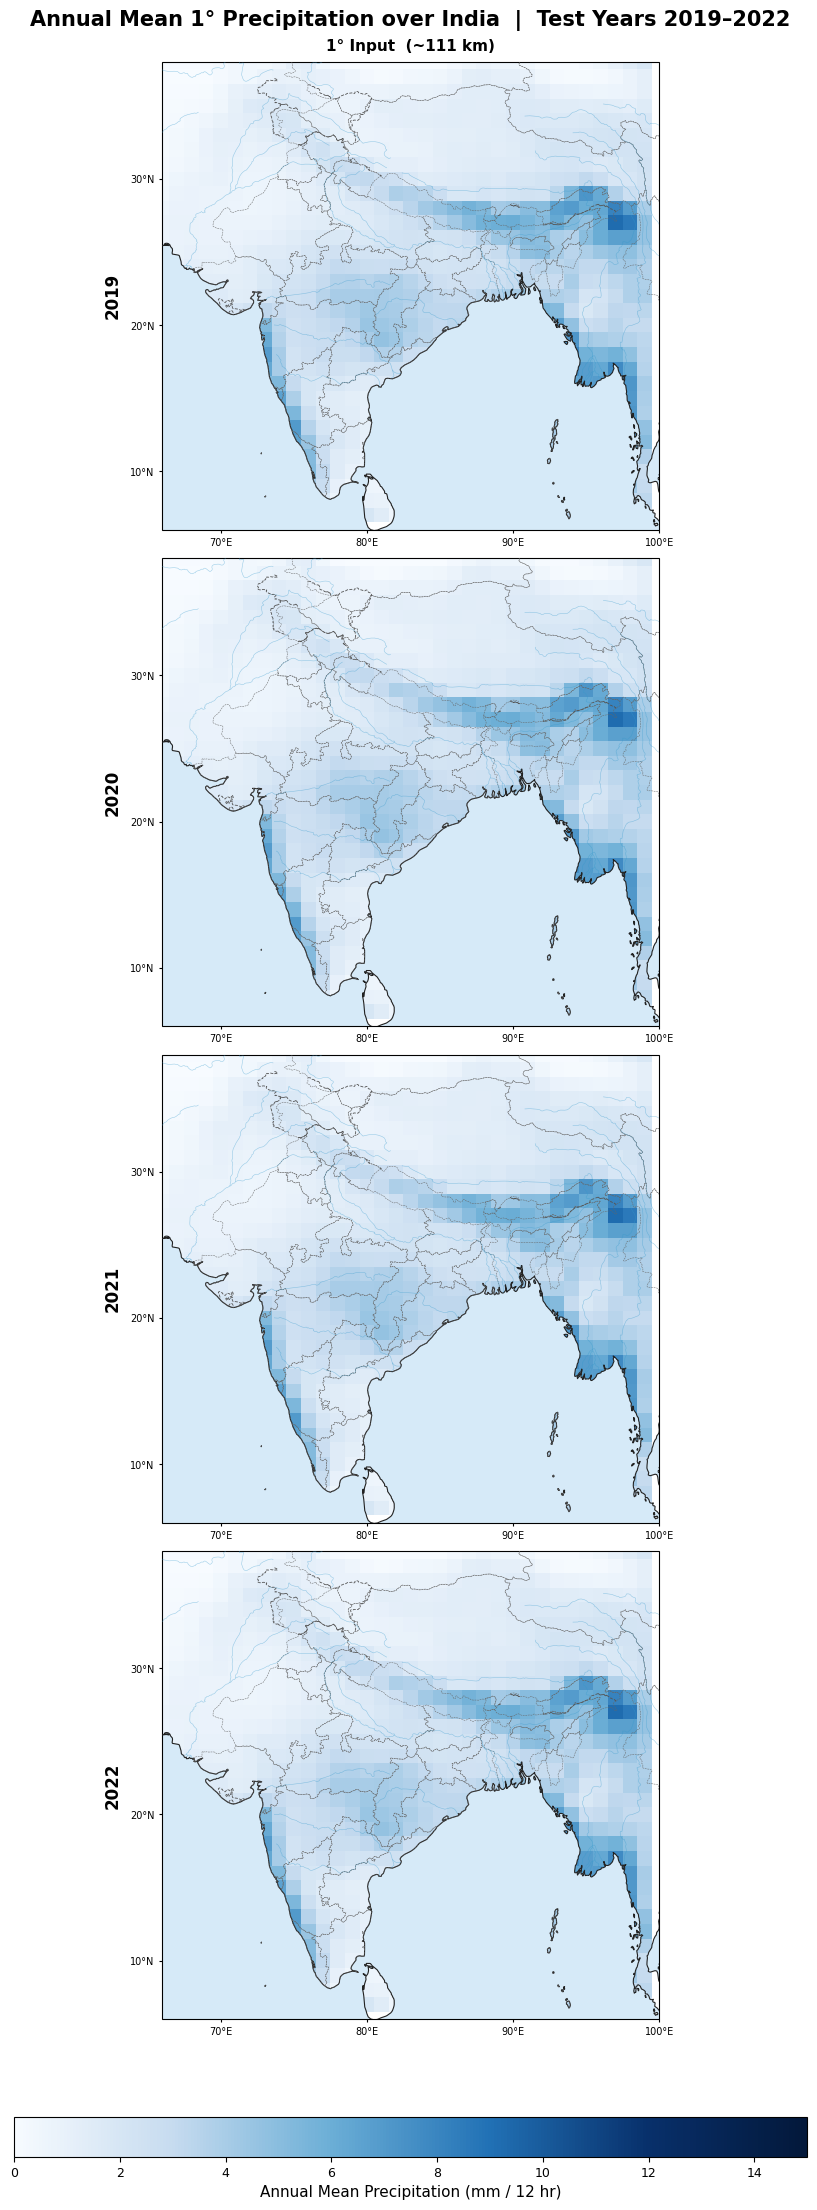

Done → /kaggle/working/india_1deg_only.png


In [19]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 4 — Year-wise India test plots  (2019 – 2022)                        ║
# ║  Rows : one per year  (mean over coarse rainfall)                          ║
# ║  Col  : 1° Input only                                                      ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import torch
from torch.utils.data import DataLoader

# ── Region ────────────────────────────────────────────────────────────────────
LAT_MIN, LAT_MAX =  6.0, 38.0
LON_MIN, LON_MAX = 66.0, 100.0

# ── Colormap ──────────────────────────────────────────────────────────────────
_blue_colors  = ['#f7fbff', '#c6dbef', '#6baed6', '#2171b5', '#08306b', '#03183a']
cmap_tp       = mcolors.LinearSegmentedColormap.from_list('tp_blue', _blue_colors, N=256)

VMIN_TP, VMAX_TP = 0, 15

# ── Cartopy setup ─────────────────────────────────────────────────────────────
_proj = ccrs.PlateCarree()
_ne_disputed = cfeature.NaturalEarthFeature(
    category='cultural',
    name='admin_0_boundary_lines_disputed_areas',
    scale='10m',
    facecolor='none',
    edgecolor='#555555'
)

def _decorate(ax):
    ax.add_feature(cfeature.OCEAN, facecolor='#d6eaf8', zorder=2)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='#222222', zorder=3)
    ax.add_feature(cfeature.STATES, linewidth=0.35, edgecolor='#666666',
                   linestyle='--', zorder=3)
    ax.add_feature(_ne_disputed, linewidth=0.6, linestyle='--', zorder=10)
    ax.add_feature(cfeature.RIVERS, linewidth=0.4, edgecolor='#3399cc',
                   alpha=0.45, zorder=3)

    ax.set_extent([LON_MIN, LON_MAX, LAT_MIN, LAT_MAX], crs=_proj)
    ax.set_xticks(np.arange(70, 101, 10), crs=_proj)
    ax.set_yticks(np.arange(10, 38, 10), crs=_proj)

    ax.xaxis.set_major_formatter(LongitudeFormatter())
    ax.yaxis.set_major_formatter(LatitudeFormatter())
    ax.tick_params(labelsize=7, length=2)


def _pcolor(ax, lons, lats, vals):
    lons2d, lats2d = np.meshgrid(lons, lats)
    return ax.pcolormesh(
        lons2d, lats2d, vals,
        cmap=cmap_tp,
        vmin=VMIN_TP,
        vmax=VMAX_TP,
        transform=_proj,
        shading='auto',
        zorder=1
    )


# ── Zarr path ─────────────────────────────────────────────────────────────────
zarr_path = (
    "gs://weatherbench2/datasets/era5/"
    "1959-2023_01_10-wb13-6h-1440x721_with_derived_variables.zarr"
)

TEST_YEARS = [2019, 2020, 2021, 2022]

# ── Collect per-year mean fields ──────────────────────────────────────────────
year_data = {}

for year in TEST_YEARS:
    print(f"  Processing {year} …", end=" ", flush=True)

    # test_ds     = UpscaleDataset(zarr_path=zarr_path, year_start=year, year_end=year)
    # test_loader = DataLoader(test_ds, batch_size=8, shuffle=False, num_workers=2)

    all_coarse = []

    for b in test_loader:
        all_coarse.append(b["coarse"])

    coarse_t = torch.cat(all_coarse)   # (N, C, H, W)

    ds_lats = test_ds.lat.values.astype(np.float32)
    ds_lons = test_ds.lon.values.astype(np.float32)

    IN_SCALE = 4
    ds_lats_1 = ds_lats[::IN_SCALE]
    ds_lons_1 = ds_lons[::IN_SCALE]

    # ── Mean rainfall (mm) ────────────────────────────────────────────────────
    arr = coarse_t[:, 0].numpy()
    mean_full = np.expm1(arr.mean(axis=0))
    mean_1deg = mean_full[::IN_SCALE, ::IN_SCALE]

    year_data[year] = dict(
        input_1deg = mean_1deg*1.4,
        lat_1      = ds_lats_1,
        lon_1      = ds_lons_1,
    )

    print("done")


# ── Build 4 × 1 figure ────────────────────────────────────────────────────────
fig, axes = plt.subplots(
    4, 1,
    figsize=(10, 22),
    subplot_kw={'projection': _proj},
    constrained_layout=True,
)

fig.suptitle(
    'Annual Mean 1° Precipitation over India  |  Test Years 2019–2022',
    fontsize=15, fontweight='bold',
)

axes[0].set_title('1° Input  (~111 km)', fontsize=11, fontweight='bold', pad=8)

for row_idx, year in enumerate(TEST_YEARS):
    d = year_data[year]

    ax = axes[row_idx]
    _pcolor(ax, d["lon_1"], d["lat_1"], d["input_1deg"])
    _decorate(ax)

    ax.set_ylabel(str(year), fontsize=12, fontweight='bold', labelpad=6)


# ── Colorbar ─────────────────────────────────────────────────────────────────
sm = plt.cm.ScalarMappable(
    cmap=cmap_tp,
    norm=plt.Normalize(vmin=VMIN_TP, vmax=VMAX_TP)
)
sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=axes,
    orientation='horizontal',
    fraction=0.025,
    pad=0.04,
    shrink=0.8
)

cbar.set_label('Annual Mean Precipitation (mm / 12 hr)', fontsize=11)
cbar.ax.tick_params(labelsize=9)


# ── Save & show ───────────────────────────────────────────────────────────────
SAVE_PATH = "/kaggle/working/india_1deg_only.png"
plt.savefig(SAVE_PATH, dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print(f"Done → {SAVE_PATH}")

In [10]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 5 — GenCast → UNet Super-Resolution  (2019 – 2022)                   ║
# ║  GenCast 1° preds loaded from HuggingFace, fed through trained UNet         ║
# ║  Rows : 2019 · 2020 · 2021 · 2022                                           ║
# ║  Cols : GenCast 1° Input  |  UNet 0.25° Pred  |  ERA5 Actual 0.25°  |  Err ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import numpy as np
import torch
import torch.nn.functional as F
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from huggingface_hub import hf_hub_download
from torch.utils.data import DataLoader

# ─────────────────────────────────────────────────────────────────────────────
#  CONFIG
# ─────────────────────────────────────────────────────────────────────────────
REPO_ID    = "priyanshus9913/Result_MTP_12"
# TEST_YEARS = [2022]

TEST_YEARS = [2019, 2020, 2021, 2022]

LAT_MIN, LAT_MAX =  6.0, 38.0
LON_MIN, LON_MAX = 66.0, 100.0

VMIN_TP,  VMAX_TP  =  0,  15    # mm / 12 hr  (seasonal mean after expm1)
VMAX_ERR           =  8         # ± mm for diverging error colorbar

zarr_path = (
    "gs://weatherbench2/datasets/era5/"
    "1959-2023_01_10-wb13-6h-1440x721_with_derived_variables.zarr"
)

# ─────────────────────────────────────────────────────────────────────────────
#  COLORMAPS  (identical to Cell 4)
# ─────────────────────────────────────────────────────────────────────────────
_blue_cols = ['#f7fbff', '#c6dbef', '#6baed6', '#2171b5', '#08306b', '#03183a']
cmap_tp    = mcolors.LinearSegmentedColormap.from_list('tp_blue', _blue_cols, N=256)

_err_cols  = ['#2166ac', '#92c5de', '#f7f7f7', '#f4a582', '#d6604d', '#b2182b']
cmap_err   = mcolors.LinearSegmentedColormap.from_list('err_div', _err_cols,  N=256)

# ─────────────────────────────────────────────────────────────────────────────
#  CARTOPY HELPERS  (identical style to Cell 4)
# ─────────────────────────────────────────────────────────────────────────────
_proj       = ccrs.PlateCarree()
_ne_disputed = cfeature.NaturalEarthFeature(
    category='cultural', name='admin_0_boundary_lines_disputed_areas',
    scale='10m', facecolor='none', edgecolor='#555555'
)

def _decorate(ax):
    ax.add_feature(cfeature.OCEAN,     facecolor='#d6eaf8', zorder=2)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8,  edgecolor='#222222', zorder=3)
    ax.add_feature(cfeature.STATES,    linewidth=0.35, edgecolor='#666666',
                   linestyle='--', zorder=3)
    ax.add_feature(_ne_disputed,       linewidth=0.6,  linestyle='--', zorder=10)
    ax.add_feature(cfeature.RIVERS,    linewidth=0.4,  edgecolor='#3399cc',
                   alpha=0.45, zorder=3)
    ax.set_extent([LON_MIN, LON_MAX, LAT_MIN, LAT_MAX], crs=_proj)
    ax.set_xticks(np.arange(70, 101, 10), crs=_proj)
    ax.set_yticks(np.arange(10,  38, 10), crs=_proj)
    ax.xaxis.set_major_formatter(LongitudeFormatter())
    ax.yaxis.set_major_formatter(LatitudeFormatter())
    ax.tick_params(labelsize=7, length=2)

def _pcolor(ax, lons, lats, vals, cmap, vmin, vmax):
    lons2d, lats2d = np.meshgrid(lons, lats)
    return ax.pcolormesh(lons2d, lats2d, vals,
                         cmap=cmap, vmin=vmin, vmax=vmax,
                         transform=_proj, shading='auto', zorder=1)

# ─────────────────────────────────────────────────────────────────────────────
#  LOAD GENCAST PREDICTIONS FROM HUGGINGFACE
# ─────────────────────────────────────────────────────────────────────────────
def load_gencast_year(year: int) -> xr.Dataset:
    """
    Downloads June (06) and August (08) GenCast NetCDF files for `year`,
    crops to India, and returns a single combined xr.Dataset.

    Variables kept : total_precipitation_12hr
    Dimensions     : target_time, latitude, longitude
    Resolution     : 1°  (as stored in HuggingFace)
    Units          : metres  →  converted to mm  (* 1000)
    """
    ds_list = []
    for m in ["06", "08"]:
        filename = f"{year}_{m}/preds_combined_{year}_{m}.nc"
        path = hf_hub_download(
            repo_id=REPO_ID,
            filename=filename,
            repo_type="dataset",
        )
        print(f"  📂 {filename}", end=" … ")
        ds = xr.open_dataset(path)

        # ── Drop singleton/unwanted dims: time (lead step), level ────────────
        for dim in ["time", "level", "batch", "member", "realization", "sample"]:
            if dim in ds.dims:
                ds = ds.isel(**{dim: 0})

        # ── Keep only precipitation ───────────────────────────────────────────
        ds = ds[["total_precipitation_12hr"]]

        # ── Normalise coord names → latitude / longitude ──────────────────────
        rename = {}
        if "lat" in ds.coords and "latitude" not in ds.coords:
            rename["lat"] = "latitude"
        if "lon" in ds.coords and "longitude" not in ds.coords:
            rename["lon"] = "longitude"
        if rename:
            ds = ds.rename(rename)

        # ── Remap 0–360 → -180–180 ────────────────────────────────────────────
        if float(ds.longitude.max()) > 180:
            ds = ds.assign_coords(
                longitude=((ds.longitude.values + 180) % 360) - 180
            ).sortby("longitude")

        # ── latitude may be ascending (-90→90); sortby to ensure descending ───
        if ds.latitude.values[0] < ds.latitude.values[-1]:
            ds = ds.sortby("latitude", ascending=False)

        # ── Crop to India ─────────────────────────────────────────────────────
        ds = ds.sel(
            latitude  = slice(LAT_MAX + 1, LAT_MIN - 1),
            longitude = slice(LON_MIN - 1, LON_MAX + 1),
        )

        # ── Convert m → mm ────────────────────────────────────────────────────
        ds["total_precipitation_12hr"] = ds["total_precipitation_12hr"] * 1000.0

        print(f"shape after crop: {dict(ds.dims)}")
        ds_list.append(ds)
        print("ok")

    # Combine both monsoon sub-seasons along the time dimension
    combined = xr.concat(ds_list, dim="target_time")
    print(f"  ✅ GenCast {year}: {combined.dims}")
    return combined


# ─────────────────────────────────────────────────────────────────────────────
#  LOAD MODEL CHECKPOINT
# ─────────────────────────────────────────────────────────────────────────────
device = "cuda" if torch.cuda.is_available() else "cpu"
ckpt   = torch.load("/kaggle/working/best_model.pt", map_location=device)

# Re-use channel count from the training dataset (still in memory)
model = UNet(
    in_c  = train_ds.inputs.shape[1],
    out_c = train_ds.targets.shape[1],
).to(device)
model.load_state_dict(ckpt["model_state"])
model.eval()
print("✓ Model loaded from checkpoint")

# ─────────────────────────────────────────────────────────────────────────────
#  BUILD A LIGHTWEIGHT DATASET-LIKE WRAPPER FOR GENCAST INPUT
# ─────────────────────────────────────────────────────────────────────────────
# The UNet expects:
#   inputs  : (N, C_in, H, W)  — normalised (coarse + constants)
#   cond    : (N, 2)           — [day_of_year_norm, hour_norm]
#   fine    : (N, 1, H, W)    — for computing ERA5 actual
#
# GenCast preds replace the "coarse ERA5" that was used during training.
# We replicate exactly the same preprocessing steps from UpscaleDataset:
#   1. log1p(tp_mm)
#   2. bilinear upsample 1° → same H×W as fine ERA5 grid
#   3. normalise (coarse - mean) / std   [per dataset statistics]
#   4. append constants from train_ds (land-sea mask, geopotential)

IN_SCALE = 4   # must match UpscaleDataset(in_scale=4)

def preprocess_gencast_as_coarse(
    gc_tp_mm: np.ndarray,    # (T, H_1deg, W_1deg)
    target_H: int,
    target_W: int,
    train_mean: float,
    train_std:  float,
) -> torch.Tensor:
    """
    Applies the same coarse-preprocessing the training dataset used,
    returning a (T, 1, H_fine, W_fine) tensor ready for UNet input.
    """
    # log1p
    arr = np.log1p(gc_tp_mm).astype(np.float32)          # (T, H1, W1)
    t   = torch.from_numpy(arr).unsqueeze(1)              # (T, 1, H1, W1)
    # upsample to fine grid
    t   = F.interpolate(t, size=(target_H, target_W), mode="bilinear",
                        align_corners=False)               # (T, 1, H, W)
    # normalise with training stats
    t   = (t - train_mean) / train_std
    return t                                              # (T, 1, H, W)


# ─────────────────────────────────────────────────────────────────────────────
#  PER-YEAR INFERENCE
# ─────────────────────────────────────────────────────────────────────────────
# We also need ERA5 actuals at 0.25° for the "Actual" and "Error" columns.
# Reuse UpscaleDataset for that — it already has fine + lat/lon.

year_data = {}

for year in TEST_YEARS:
    print(f"\n{'─'*60}\n  Year {year}")

    # ── 1. Load GenCast preds ─────────────────────────────────────────────────
    gc_ds = load_gencast_year(year)

    gc_lat = gc_ds.latitude.values.astype(np.float32)    # 1° grid, descending
    gc_lon = gc_ds.longitude.values.astype(np.float32)   # 1° grid, ascending
    gc_tp  = gc_ds["total_precipitation_12hr"].values     # (T, H1, W1)  mm
    # squeeze out any leftover size-1 dims (e.g. ensemble member)
    gc_tp  = gc_tp.squeeze()
    if gc_tp.ndim == 2:                                   # single timestep edge case
        gc_tp = gc_tp[np.newaxis]
    print(f"  gc_tp shape: {gc_tp.shape}  lat: {gc_lat.shape}  lon: {gc_lon.shape}")

    # # ── 2. Load ERA5 actuals via UpscaleDataset (monsoon months only) ─────────
    
    # era5_ds = UpscaleDataset(
    #     zarr_path=zarr_path,
    #     year_start=year, year_end=year,
    # )
    
    era5_lats = era5_ds.lat.values.astype(np.float32)    # 0.25° fine grid
    era5_lons = era5_ds.lon.values.astype(np.float32)
    H_fine, W_fine = era5_ds.fine.shape[-2], era5_ds.fine.shape[-1]

    # Training-time normalisation stats (from the training dataset)
    train_mean = float(train_ds.inputs[:, 0].mean())
    train_std  = float(train_ds.inputs[:, 0].std())

    # ── 3. Align GenCast time axis to ERA5 timestamps ─────────────────────────
    # GenCast target_time → select only those present in era5_ds
    # Both cover monsoon months (Jun–Sep) for the same year.
    # Simplest: take min(T_gc, T_era5) and use them positionally.
    T_gc   = gc_tp.shape[0]
    T_era5 = era5_ds.fine.shape[0]
    T      = min(T_gc, T_era5)
    print(f"  GenCast steps: {T_gc}   ERA5 steps: {T_era5}   Using: {T}")

    gc_tp_aligned = gc_tp[:T]                            # (T, H1, W1)

    # ── 4. Build UNet input tensor ────────────────────────────────────────────
    coarse_gc = preprocess_gencast_as_coarse(
        gc_tp_aligned, H_fine, W_fine, train_mean, train_std
    )                                                    # (T, 1, H, W)

    # Append constants  (channels 1+ from training inputs: land-sea mask, Z)
    # train_ds.inputs shape: (N, C_in, H, W); constant channels = C_in - 1
    const_channels = train_ds.inputs.shape[1] - 1
    if const_channels > 0:
        # Take constant slice from the first sample (they're time-invariant)
        consts = train_ds.inputs[0, 1:, :, :]           # (C_const, H, W)
        consts = consts.unsqueeze(0).expand(T, -1, -1, -1)  # (T, C_const, H, W)
        inputs_gc = torch.cat([coarse_gc, consts], dim=1)   # (T, C_in, H, W)
    else:
        inputs_gc = coarse_gc

    # Time embeddings matching era5_ds order
    doy_norm  = era5_ds.day_of_year[:T]                  # (T,)
    hour_norm = era5_ds.hour[:T]                         # (T,)

    # ── 5. Run UNet in batches ────────────────────────────────────────────────
    BATCH = 8
    all_preds = []
    with torch.no_grad():
        for i in range(0, T, BATCH):
            x_b    = inputs_gc[i:i+BATCH].to(device)
            cond_b = torch.stack(
                (doy_norm[i:i+BATCH], hour_norm[i:i+BATCH]), dim=1
            ).to(device)
            pred_b = model(x_b, cond_b)                  # (B, 1, H, W)  residual

            # coarse for this batch (un-normalised log1p)
            coarse_b = F.interpolate(
                torch.from_numpy(
                    np.log1p(gc_tp_aligned[i:i+BATCH].astype(np.float32))
                ).unsqueeze(1),
                size=(H_fine, W_fine), mode="bilinear", align_corners=False,
            )                                            # (B, 1, H, W)

            fine_pred = era5_ds.residual_to_fine(pred_b.cpu(), coarse_b)
            all_preds.append(fine_pred)

    preds_t = torch.cat(all_preds)                       # (T, 1, H, W)  log1p mm

    # ── 6. Compute display fields (mean over T, undo log1p) ───────────────────
    def _mean_mm(t):
        return np.expm1(t[:, 0].numpy().mean(axis=0))   # (H, W)  mm

    pred_025   = _mean_mm(preds_t)
    actual_025 = _mean_mm(era5_ds.fine[:T])

    # GenCast 1° mean for display column 0
    gc_mean_1deg = gc_tp_aligned.mean(axis=0)            # (H1, W1)  already mm

    # also store full (T, H, W) arrays in mm for proper CRPS in Cell 6
    pred_full   = np.expm1(preds_t[:, 0].numpy())           # (T, H, W)  mm
    actual_full = np.expm1(era5_ds.fine[:T, 0].numpy())     # (T, H, W)  mm

    year_data[year] = dict(
        gc_1deg     = gc_mean_1deg,
        pred_025    = pred_025,
        actual_025  = actual_025,
        pred_full   = pred_full,    # (T, H, W) mm — for CRPS
        actual_full = actual_full,  # (T, H, W) mm — for CRPS
        lat_1       = gc_lat,
        lon_1       = gc_lon,
        lat_025     = era5_lats,
        lon_025     = era5_lons,
    )
    print(f"  ✓ {year} done")

# ─────────────────────────────────────────────────────────────────────────────
#  PLOT  4 × 4
# ─────────────────────────────────────────────────────────────────────────────
COL_TITLES = [
    'GenCast 1° Input  (~111 km)',
    'UNet 0.25° Pred  (~28 km)',
    'ERA5 Actual 0.25°  (~28 km)',
    'Error  (Pred − Actual)',
]

fig, axes = plt.subplots(
    4, 4,
    figsize=(22, 22),
    subplot_kw={'projection': _proj},
    constrained_layout=True,
)

fig.suptitle(
    'Monsoon Precipitation over India  |  GenCast → UNet Super-Resolution  |  2019–2022',
    fontsize=15, fontweight='bold',
)

for col, title in enumerate(COL_TITLES):
    axes[0, col].set_title(title, fontsize=11, fontweight='bold', pad=8)

for row_idx, year in enumerate(TEST_YEARS):
    d     = year_data[year]
    error = d["pred_025"] - d["actual_025"]

    plots = [
        (d["gc_1deg"],    d["lat_1"],   d["lon_1"],   cmap_tp,  VMIN_TP,   VMAX_TP ),
        (d["pred_025"],   d["lat_025"], d["lon_025"], cmap_tp,  VMIN_TP,   VMAX_TP ),
        (d["actual_025"], d["lat_025"], d["lon_025"], cmap_tp,  VMIN_TP,   VMAX_TP ),
        (error,           d["lat_025"], d["lon_025"], cmap_err, -VMAX_ERR, VMAX_ERR),
    ]

    for col_idx, (vals, lats, lons, cmap, vmin, vmax) in enumerate(plots):
        ax = axes[row_idx, col_idx]
        _pcolor(ax, lons, lats, vals, cmap, vmin, vmax)
        _decorate(ax)
        if col_idx == 0:
            ax.set_ylabel(str(year), fontsize=12, fontweight='bold', labelpad=6)

# ── Shared colorbars ──────────────────────────────────────────────────────────
sm_tp = plt.cm.ScalarMappable(cmap=cmap_tp,
                               norm=plt.Normalize(vmin=VMIN_TP, vmax=VMAX_TP))
sm_tp.set_array([])
cbar_tp = fig.colorbar(sm_tp, ax=axes[:, :3], orientation='horizontal',
                        fraction=0.025, pad=0.04, shrink=0.80)
cbar_tp.set_label('Mean Precipitation (mm / 12 hr)', fontsize=11)
cbar_tp.ax.tick_params(labelsize=9)

sm_err = plt.cm.ScalarMappable(cmap=cmap_err,
                                norm=plt.Normalize(vmin=-VMAX_ERR, vmax=VMAX_ERR))
sm_err.set_array([])
cbar_err = fig.colorbar(sm_err, ax=axes[:, 3], orientation='horizontal',
                         fraction=0.025, pad=0.04, shrink=0.80)
cbar_err.set_label('Error  (Pred − Actual)  (mm / 12 hr)', fontsize=11)
cbar_err.ax.tick_params(labelsize=9)

SAVE_PATH = "/kaggle/working/india_gencast_yearwise.png"
plt.savefig(SAVE_PATH, dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f"\nDone → {SAVE_PATH}")

✓ Model loaded from checkpoint

────────────────────────────────────────────────────────────
  Year 2019


2019_06/preds_combined_2019_06.nc:   0%|          | 0.00/1.87G [00:00<?, ?B/s]

  📂 2019_06/preds_combined_2019_06.nc … 

/tmp/ipykernel_55/609884534.py:138: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"shape after crop: {dict(ds.dims)}")


shape after crop: {'target_time': 121, 'latitude': 35, 'longitude': 37}
ok


2019_08/preds_combined_2019_08.nc:   0%|          | 0.00/1.87G [00:00<?, ?B/s]

  📂 2019_08/preds_combined_2019_08.nc … 

/tmp/ipykernel_55/609884534.py:138: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"shape after crop: {dict(ds.dims)}")


shape after crop: {'target_time': 121, 'latitude': 35, 'longitude': 37}
ok
  ✅ GenCast 2019: FrozenMappingWarningOnValuesAccess({'target_time': 242, 'latitude': 35, 'longitude': 37})
  gc_tp shape: (242, 35, 37)  lat: (35,)  lon: (37,)

Opening ERA5 Zarr...
in_scale = 4


KeyboardInterrupt: 